# Exploratory Data Analysis (EDA)

Objective:
Explore Bitcoin price behavior, returns, volatility, and relationships between variables.

Dataset:
Bitcoin Historical Market Data (2014–2026)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../data/raw/bitcoin_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

In [8]:
def save_plot(name):
    plt.savefig(
        f"../figures/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

## Price History Analysis

Objective:
Visualize Bitcoin's long-term price evolution.

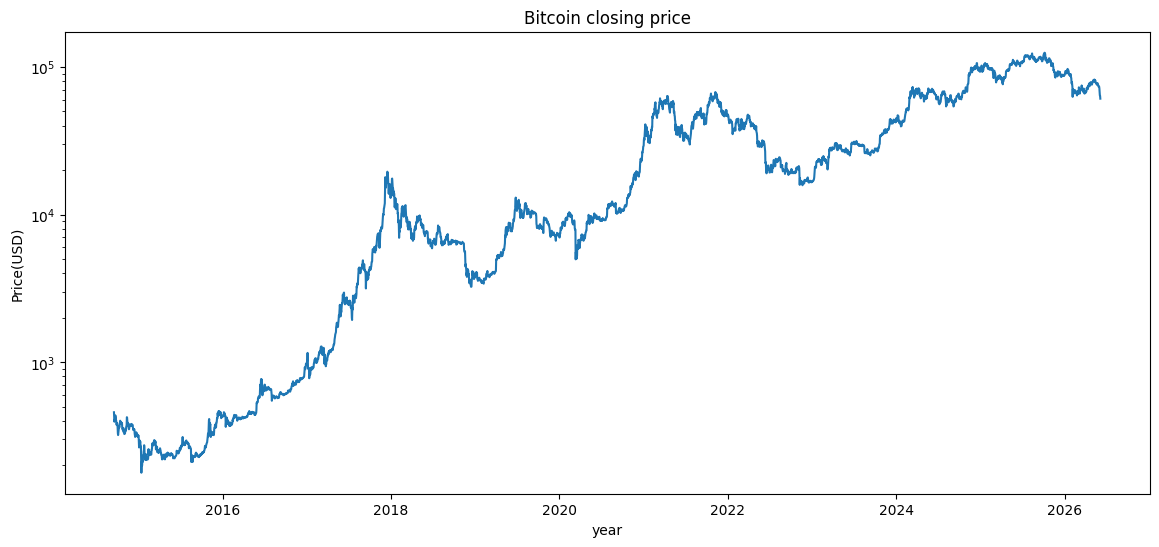

In [9]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Close"])
plt.yscale("log")
plt.xlabel("year")
plt.ylabel("Price(USD)")
plt.title("Bitcoin closing price")
save_plot("price")
plt.show()

### Findings

- Bitcoin exhibited exponential long-term growth.
- Multiple bull and bear market cycles are visible.
- Significant drawdowns occurred during major market events.

## Daily Return Analysis

Objective:
Measure day-to-day percentage changes in Bitcoin prices.

In [11]:
df["Daily_return"]=df["Close"].pct_change()
print(df[["Date","Close","Daily_return"]].head(10))
df["Daily_return"].describe()

        Date       Close  Daily_return
0 2014-09-17  457.334015           NaN
1 2014-09-18  424.440002     -0.071926
2 2014-09-19  394.795990     -0.069843
3 2014-09-20  408.903992      0.035735
4 2014-09-21  398.821014     -0.024659
5 2014-09-22  402.152008      0.008352
6 2014-09-23  435.790985      0.083647
7 2014-09-24  423.204987     -0.028881
8 2014-09-25  411.574005     -0.027483
9 2014-09-26  404.424988     -0.017370


count    4279.000000
mean        0.001758
std         0.034916
min        -0.371695
25%        -0.012617
50%         0.001073
75%         0.015884
max         0.252472
Name: Daily_return, dtype: float64

In [12]:
best_day=df.loc[df["Daily_return"].idxmax()]
worst_day=df.loc[df["Daily_return"].idxmin()]
print("best_day")
print(best_day[["Date","Close","Daily_return"]])
print()
print("worst_day")
print(worst_day[["Date","Close","Daily_return"]])

best_day
Date            2017-12-07 00:00:00
Close                  17899.699219
Daily_return               0.252472
Name: 1177, dtype: object

worst_day
Date            2020-03-12 00:00:00
Close                   4970.788086
Daily_return              -0.371695
Name: 2003, dtype: object


### Findings

Largest Gain:
- 2017-12-07
- +25.25%

Largest Loss:
- 2020-03-12
- -37.17%

The COVID-19 crash produced the largest single-day decline in the dataset.

## Return Distribution

Objective:
Understand the distribution of daily returns.

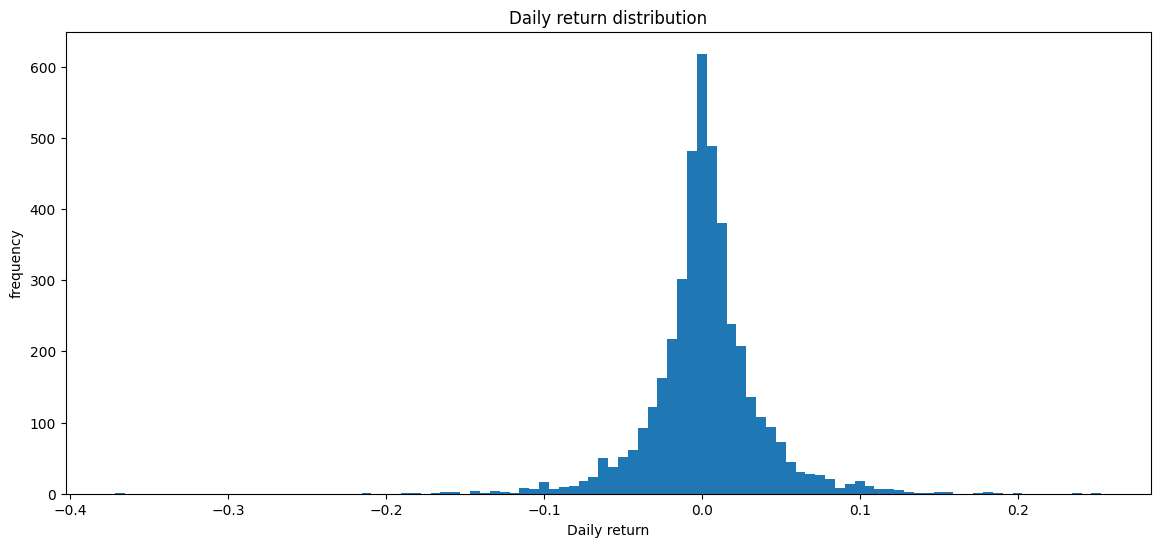

In [13]:
plt.figure(figsize=(14,6))
plt.hist(df["Daily_return"].dropna(),bins=100)
plt.title("Daily return distribution")
plt.xlabel("Daily return")
plt.ylabel("frequency")
save_plot("Daily_return_destribution")
plt.show()

### Findings

- Most returns cluster around 0%.
- Extreme gains and losses are rare.
- Distribution exhibits heavy tails.

## Volatility Analysis

Objective:
Measure rolling market risk using 30-day volatility.

In [14]:
df["Volatility"]=df["Daily_return"].rolling(30).std()

In [15]:
df["Volatility"].describe()

count    4250.000000
mean        0.031658
std         0.014492
min         0.007095
25%         0.021524
50%         0.028636
75%         0.038794
max         0.091330
Name: Volatility, dtype: float64

In [16]:
print(df["Volatility"].head(35))

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9          NaN
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
15         NaN
16         NaN
17         NaN
18         NaN
19         NaN
20         NaN
21         NaN
22         NaN
23         NaN
24         NaN
25         NaN
26         NaN
27         NaN
28         NaN
29         NaN
30    0.039148
31    0.037290
32    0.035033
33    0.034508
34    0.034284
Name: Volatility, dtype: float64


In [17]:
max_vol=df.loc[df["Volatility"].idxmax()]
print(max_vol[["Date","Close","Volatility"]])

Date          2020-04-06 00:00:00
Close                  7271.78125
Volatility                0.09133
Name: 2028, dtype: object


### Findings

Most volatility occured on 6th April 2020 due to COVID-19 market crash

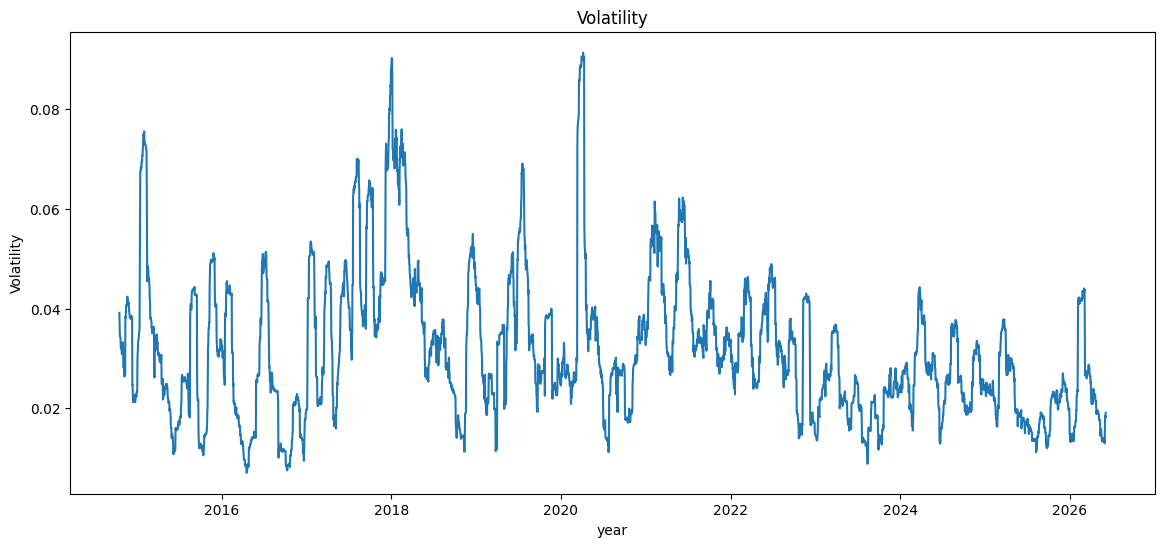

In [18]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Volatility"])
plt.title("Volatility")
plt.xlabel("year")
plt.ylabel("Volatility")
save_plot("Volatility")
plt.show()

## Hypothesis

There must be some correlation between volume and Volatility as when a market is Volatile there is most likely to be a chaos involving greater buying and selling therefore the volume must be higher for high volatility

In [19]:
df[["Volume","Volatility"]].corr()

,Volume,Volatility
Volume,1.000000,-0.024534
Volatility,-0.024534,1.000000


In [20]:
df["avg_vol_30"]=df["Volume"].rolling(30).mean()
df[["Volatility","avg_vol_30"]].corr()

,Volatility,avg_vol_30
Volatility,1.00000,-0.00464
avg_vol_30,-0.00464,1.00000


### Findings

The hypothesis was not correct as the correlation matrix show verery little correlation between the 2 factors

In [21]:
corr=df.corr(numeric_only=True)
print(corr["Volatility"].sort_values(ascending=False))

Volatility      1.000000
Daily_return    0.017981
avg_vol_30     -0.004640
Volume         -0.024534
High           -0.231001
Adj Close      -0.234677
Close          -0.234677
Open           -0.234915
Low            -0.239657
Name: Volatility, dtype: float64


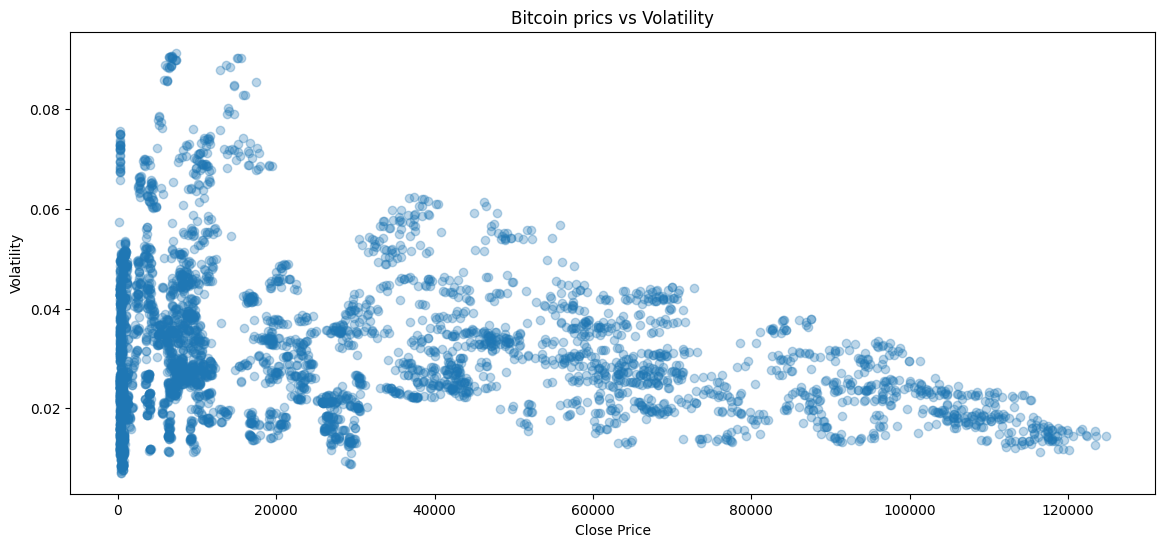

In [22]:
plt.figure(figsize=(14,6))
plt.scatter(df["Close"],df["Volatility"],alpha=0.3)
plt.xlabel("Close Price")
plt.ylabel("Volatility")
plt.title("Bitcoin prics vs Volatility")
save_plot("price_vs_volatility")
plt.show()

In [28]:
df["Year"]=df["Date"].dt.year
yearly_vol=(df.groupby("Year")["Volatility"].mean())

In [29]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Daily_return', 'Volatility', 'avg_vol_30', 'Year'],
      dtype='object')

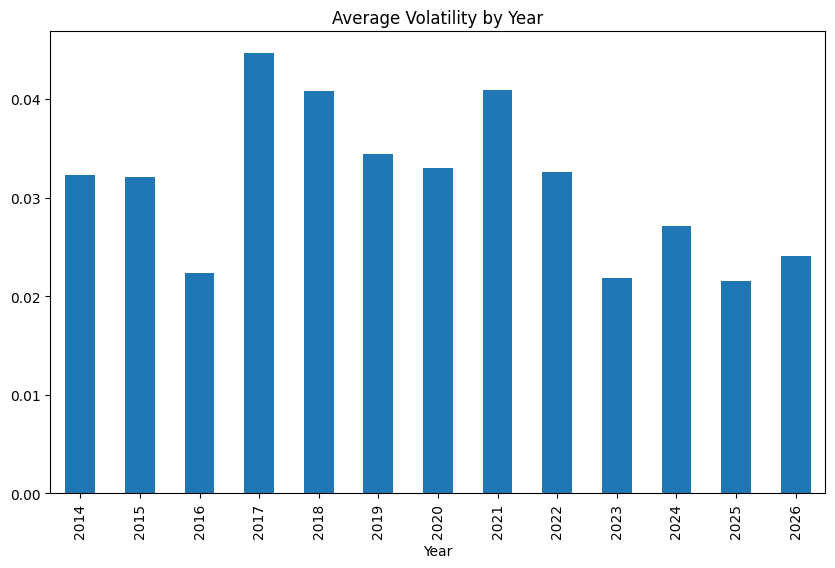

In [30]:

plt.figure(figsize=(10,6))
yearly_vol.plot(kind="bar")
plt.title("Average Volatility by Year")
save_plot("yearly_volatility")
plt.show()

# Key EDA Findings

1. Bitcoin experienced exponential long-term growth.

2. The largest single-day decline occurred during the COVID-19 crash.

3. Trading volume showed almost no relationship with volatility.

4. Volatility peaked during major market stress periods.

5. Recent years exhibit lower average volatility than earlier speculative cycles.